# Customer Churn Analysis

### Importing Libraries

In [79]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use("ggplot")
sns.set_palette("Set2")

### Loading Dataset

In [103]:
df = pd.read_csv('00_Customer_Churn_dataset.csv')
# df
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


### Data Overview

In [81]:
df.shape
df.columns
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


### Data Cleaning

In [82]:
df["TotalCharges"] = df["TotalCharges"].replace(" ","0")
df["TotalCharges"] = df["TotalCharges"].astype("float")

In [83]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


### Missing Values

In [84]:
df.isnull().sum()

customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

### Duplicate Check

In [85]:
df.duplicated().sum()

np.int64(0)

### Summary Statistics

In [86]:
df.describe()

,SeniorCitizen,tenure,MonthlyCharges,TotalCharges
count,7043.000000,7043.000000,7043.000000,7043.000000
mean,0.162147,32.371149,64.761692,2279.734304
std,0.368612,24.559481,30.090047,2266.794470
min,0.000000,0.000000,18.250000,0.000000
25%,0.000000,9.000000,35.500000,398.550000
50%,0.000000,29.000000,70.350000,1394.550000
75%,0.000000,55.000000,89.850000,3786.600000
max,1.000000,72.000000,118.750000,8684.800000


### Churn Distribution

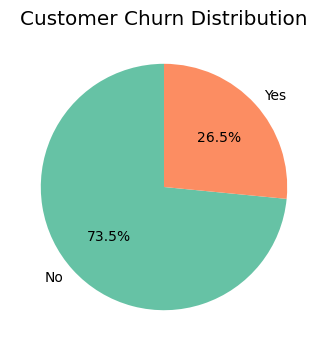

In [87]:
plt.figure(figsize=(5,4))

plt.pie(
    df["Churn"].value_counts(),
    labels=df["Churn"].value_counts().index,
    autopct="%1.1f%%",
    startangle=90
)

plt.title("Customer Churn Distribution")

plt.show()

##### Note- The majority of customers remain with the company, while a significant portion have churned, highlighting opportunities to improve customer retention.

### Churn by Gender

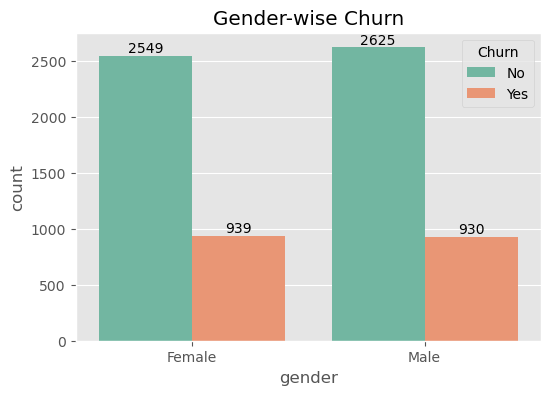

In [88]:
plt.figure(figsize=(6,4))

ax=sns.countplot(
    x="gender",
    data=df,
    hue="Churn"
)

for container in ax.containers:
    ax.bar_label(container)

plt.title("Gender-wise Churn")

plt.show()

##### Note- Male and female customers exhibit similar churn behavior, suggesting gender has minimal influence on customer retention.

### Churn by Age Group (Senior Citizens)

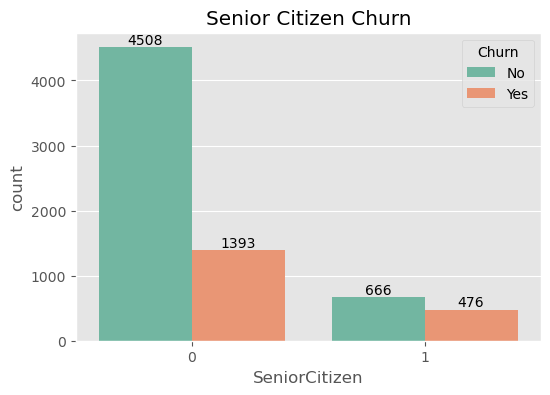

In [89]:
plt.figure(figsize=(6,4))

ax=sns.countplot(
    x="SeniorCitizen",
    data=df,
    hue="Churn"
)

for container in ax.containers:
    ax.bar_label(container)

plt.title("Senior Citizen Churn")

plt.show()

##### Note- Senior citizens have a relatively higher churn rate, indicating that this customer segment may require targeted retention strategies.

### Retention by Tenure

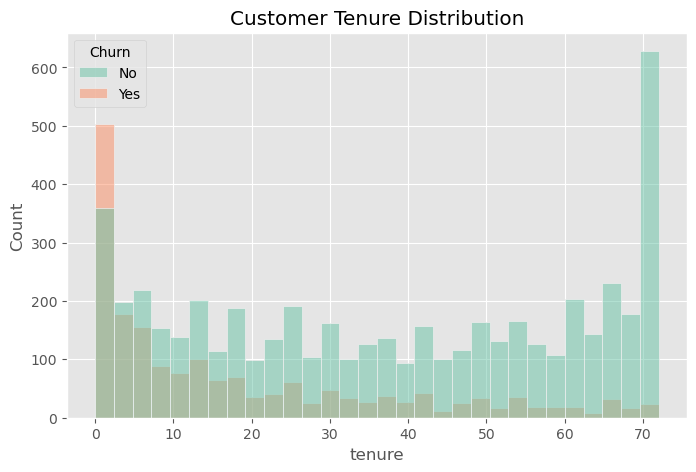

In [90]:
plt.figure(figsize=(8,5))

sns.histplot(
    data=df,
    x="tenure",
    hue="Churn",
    bins=30
)

plt.title("Customer Tenure Distribution")

plt.show()

##### Note- Customers with shorter tenure are more likely to churn, whereas long-term customers show greater loyalty.

### Monthly Billing Pattern

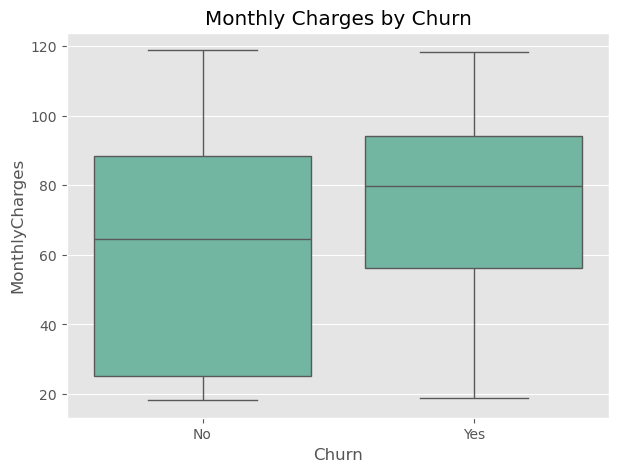

In [91]:
plt.figure(figsize=(7,5))

sns.boxplot(
    x="Churn",
    y="MonthlyCharges",
    data=df
)

plt.title("Monthly Charges by Churn")

plt.show()

##### Note- Customers paying higher monthly charges tend to churn more frequently.

### Lifetime Spending

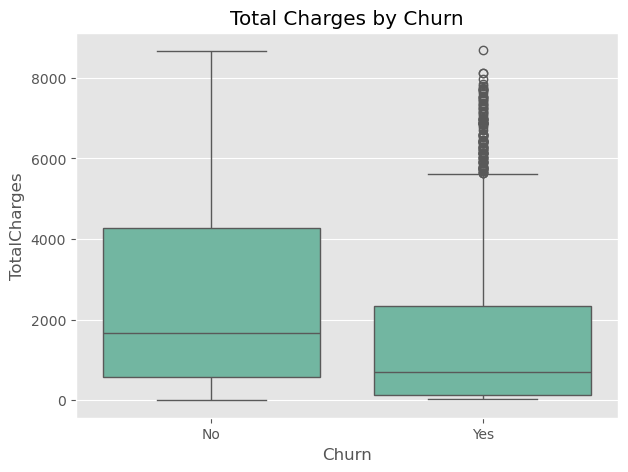

In [92]:
plt.figure(figsize=(7,5))

sns.boxplot(
    x="Churn",
    y="TotalCharges",
    data=df
)

plt.title("Total Charges by Churn")

plt.show()

##### Note- Customers with lower total charges generally represent newer customers, who are more likely to churn.

### Impact of Contract type on Churn

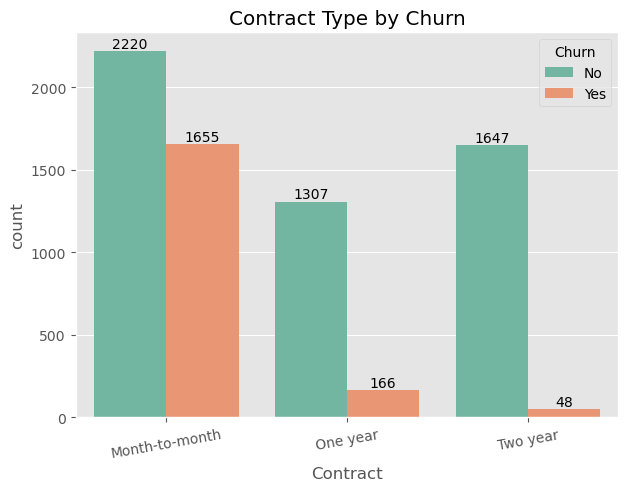

In [93]:
plt.figure(figsize=(7,5))

ax=sns.countplot(
    x="Contract",
    data=df,
    hue="Churn"
)

for container in ax.containers:
    ax.bar_label(container)

plt.xticks(rotation=10)

plt.title("Contract Type by Churn")

plt.show()

##### Note- Month-to-month contracts experience the highest churn, while long-term contracts improve customer retention.

### Internet Service Usage & Churn

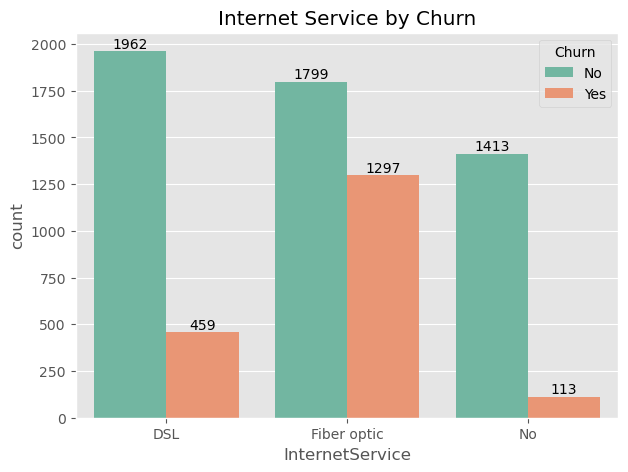

In [94]:
plt.figure(figsize=(7,5))

ax=sns.countplot(
    x="InternetService",
    data=df,
    hue="Churn"
)

for container in ax.containers:
    ax.bar_label(container)

plt.title("Internet Service by Churn")

plt.show()

##### Note- Fiber optic customers exhibit the highest churn rate, suggesting potential concerns with pricing or service quality.

### Payment Method 

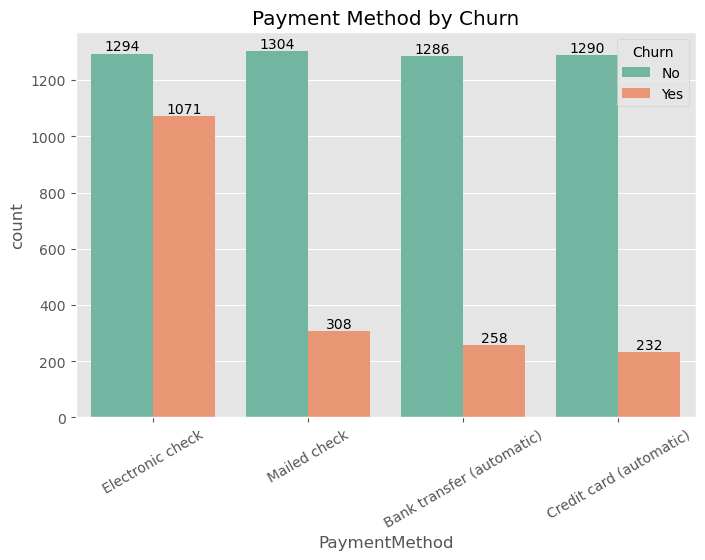

In [95]:
plt.figure(figsize=(8,5))

ax=sns.countplot(
    x="PaymentMethod",
    data=df,
    hue="Churn"
)

for container in ax.containers:
    ax.bar_label(container)

plt.xticks(rotation=30)

plt.title("Payment Method by Churn")

plt.show()

##### Note- Customers using Electronic Check tend to churn more frequently than customers using other payment methods.

### Service Usage 

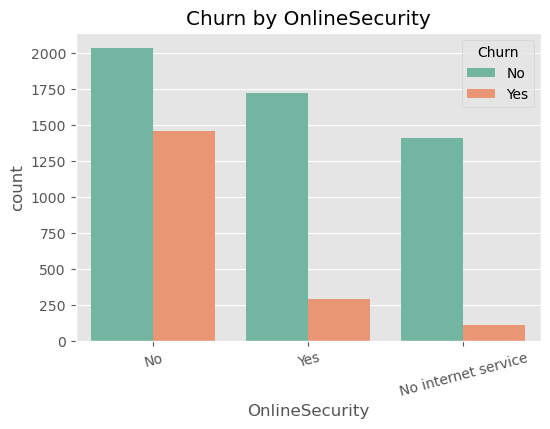

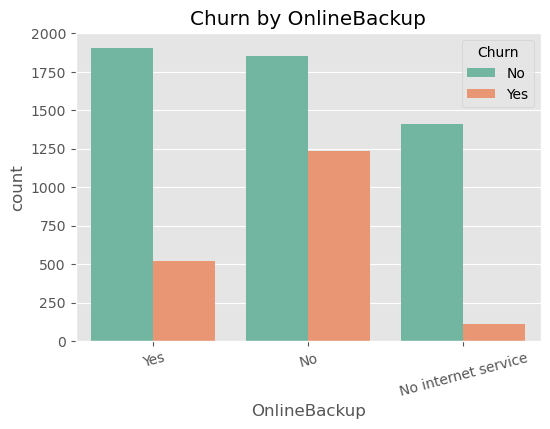

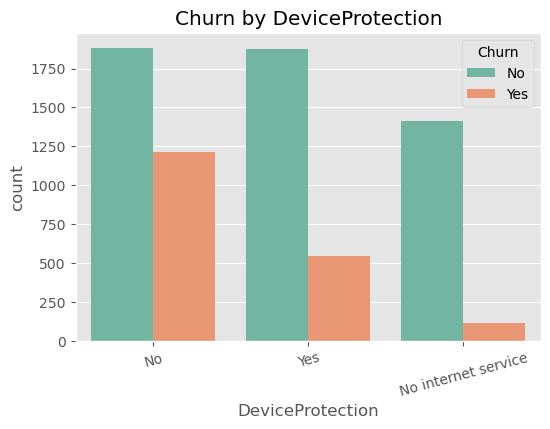

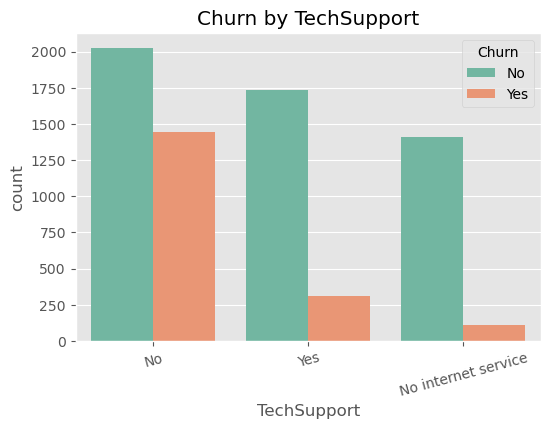

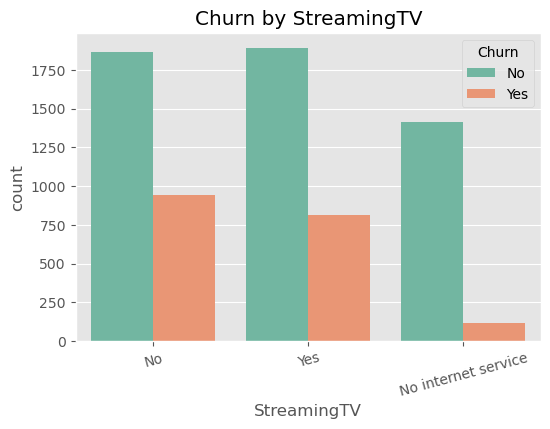

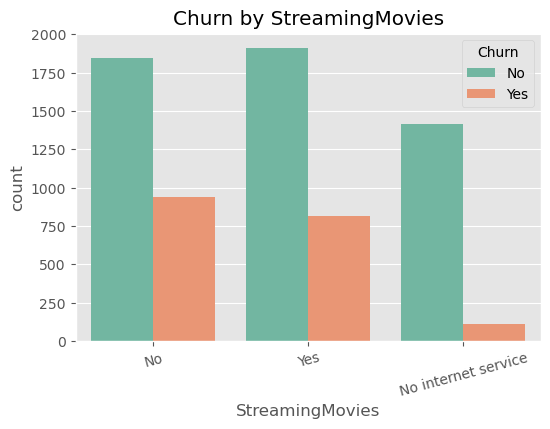

In [97]:
service_columns = [
    "OnlineSecurity",
    "OnlineBackup",
    "DeviceProtection",
    "TechSupport",
    "StreamingTV",
    "StreamingMovies"
]

for service in service_columns:

    plt.figure(figsize=(6,4))

    sns.countplot(
        data=df,
        x=service,
        hue="Churn"
    )

    plt.title(f"Churn by {service}")
    plt.xticks(rotation=15)

    plt.show()

##### Note- Customers who do not subscribe to Online Security, Online Backup, Device Protection, or Tech Support generally exhibit higher churn compared to customers who use these services. This suggests that value-added services may contribute to improved customer retention.

### Correlation Heatmap

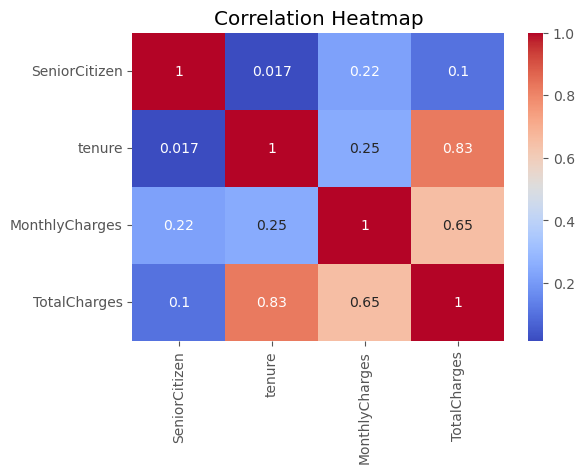

In [98]:
plt.figure(figsize=(6,4))

sns.heatmap(
    df.select_dtypes(include=np.number).corr(),
    annot=True,
    cmap="coolwarm"
)

plt.title("Correlation Heatmap")

plt.show()

##### Note- Tenure and Total Charges are strongly positively correlated, while Senior Citizen has only a weak relationship with other numerical variables.

### Business Insights:

#### 1.Customers with month-to-month contracts are more likely to leave the company than customers with one-year or two-year contracts.
    
#### 2.Customers with shorter tenure show a higher churn rate, indicating that new customers are at greater risk of leaving.

#### 3.Customers paying higher monthly charges tend to churn more often, suggesting that pricing may influence customer decisions.

#### 4.Customers using Electronic Check as their payment method have a higher churn rate compared to customers using other payment methods.

#### 5.Customers who subscribe to services such as Online Security, Tech Support, and Online Backup are generally less likely to churn, showing   that these services help improve customer retention.

### Business Recommendation
#### 1.Encourage customers to switch to long-term contracts by offering discounts or exclusive benefits.
#### 2.Improve the onboarding experience and provide regular support for new customers during their first few months.
#### 3.Review pricing plans and introduce attractive offers for customers with higher monthly charges.
#### 4.Promote Online Security, Tech Support, and Online Backup through bundled packages to increase customer retention.